In [4]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from datetime import datetime
os.environ['TZ'] = 'Europe/Berlin'
import time
time.tzset()

def checkpoint(msg):
    print(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {msg}", flush=True)

In [5]:
adata = sc.read_h5ad("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/01_extGBmap/immune_cells_extended_gbmap_hgnc.h5ad")

In [19]:

OUT_DIR = "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/05_significant_MP/05_all_immune_cells"
os.makedirs(OUT_DIR, exist_ok=True)

In [ ]:
SELECTED_MPS = ["MP1", "MP2", "MP7", "MP8", "MP9", "MP11", "MP14", "MP15", "MP19", "MP20"]

N_GENES_PER_MP = 5  # top N genes to show per MP (10 available in the file; 5 keeps the plot readable)


In [ ]:
mp_scores = pd.read_csv("/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/04_NMF_GSEAonHGNC/04_3_nmf_all_gsea_c7/mp_scores.csv", index_col=0)

mp_scores_sel = mp_scores[[f"{mp}_score" for mp in SELECTED_MPS]]
mp_scores_sel.columns = SELECTED_MPS
dominant_MP = mp_scores_sel.idxmax(axis=1)
max_scores = mp_scores_sel.max(axis=1)
threshold = np.percentile(max_scores, 75)  # top 25% of max scores
adata.obs["dominant_MP_selected"] = np.where(max_scores.values > threshold, dominant_MP.values, "Other")

In [26]:
checkpoint("Loading top genes per MP")
top_genes_df = pd.read_csv(
    "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/05_significant_MP/05_all_immune_cells/05_4_top10_genes_per_mp_sorted.csv"
)
checkpoint(f"Loaded: {top_genes_df.shape}, columns: {list(top_genes_df.columns)}")

# confirmed CSV structure: columns are "gene", "mp", "score" — long format,
# already sorted by score descending within each MP
MP_COL = "mp"
GENE_COL = "gene"

if MP_COL not in top_genes_df.columns or GENE_COL not in top_genes_df.columns:
    raise ValueError(
        f"Expected columns '{MP_COL}' and '{GENE_COL}' not found. "
        f"Actual columns: {list(top_genes_df.columns)}. Adjust MP_COL/GENE_COL above, "
        f"or if this is wide-format (one column per MP), use the alternate loading block."
    )

# build {MP: [genes]} restricted to SELECTED_MPS and top N per MP.
# explicitly sort by score descending within each MP group rather than relying
# on the CSV's row order (string-sorted MP labels, e.g. "MP1" < "MP11" < "MP2",
# don't guarantee score order is preserved/contiguous across the whole file).
SCORE_COL = "score"
if SCORE_COL not in top_genes_df.columns:
    raise ValueError(f"Expected column '{SCORE_COL}' not found. Actual columns: {list(top_genes_df.columns)}")

[2026-08-10 13:29:25] Loading top genes per MP
[2026-08-10 13:29:25] Loaded: (254, 3), columns: ['gene', 'mp', 'score']


In [27]:
mp_gene_dict = {}
for mp in SELECTED_MPS:
    mp_rows = top_genes_df.loc[top_genes_df[MP_COL] == mp].sort_values(SCORE_COL, ascending=False)
    genes = mp_rows[GENE_COL].head(N_GENES_PER_MP).tolist()
    if len(genes) == 0:
        checkpoint(f"WARNING: no genes found for {mp} — check MP naming (e.g. 'MP1' vs 'mp1' vs 1)")
    mp_gene_dict[mp] = genes

checkpoint(f"Top {N_GENES_PER_MP} genes per selected MP: {mp_gene_dict}")

# checkpoint("Loading data")
# adata = sc.read_h5ad(
#     "/net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/data/01_extGBmap/immune_cells_extended_gbmap_hgnc.h5ad"
# )
# checkpoint(f"Data loaded: {adata.n_obs} cells")

if "dominant_MP_selected" not in adata.obs.columns:
    raise ValueError(
        f"'{dominant_MP_selected}' not found in adata.obs. Available columns: {list(adata.obs.columns)}"
    )


[2026-08-10 13:29:27] Top 5 genes per selected MP: {'MP1': ['SKAP1', 'CD96', 'FYN', 'THEMIS', 'CD247'], 'MP2': ['CCL5', 'IL32', 'GZMA', 'CD3D', 'CD2'], 'MP7': ['HK2', 'CD109', 'ENSG00000258667', 'PLIN2', 'GBE1'], 'MP8': ['NUPR1', 'MT1G', 'BNIP3', 'PLIN2', 'COXFA4L3'], 'MP9': ['VCAN', 'CXCL3', 'THBS1', 'FN1', 'EREG'], 'MP11': ['STMN1', 'PCLAF', 'TYMS', 'MKI67', 'TOP2A'], 'MP14': ['C1QB', 'C1QC', 'C3', 'HAMP', 'APOE'], 'MP15': ['RPS27', 'RPS12', 'RPS15A', 'RPL21', 'S100A4'], 'MP19': ['JCHAIN', 'CD79A', 'IGKC', 'IGLC2', 'IGHM'], 'MP20': ['G0S2', 'FCGR3B', 'IL1R2', 'CXCR2', 'VNN2']}


[2026-08-10 13:33:17] adata.X max value: 8.18 (if this looks like raw counts, normalize first)
[2026-08-10 13:33:17] Plotting dotplot (top genes per MP x cell type)
[2026-08-10 13:33:21] Dotplot saved to /net/bq-storage/ag-cherrmann/bq_cinac/projects/synimmune/results/05_significant_MP/05_all_immune_cells/05_16_dotplot_top_genes_75.pdf
[2026-08-10 13:33:21] ALL DONE!


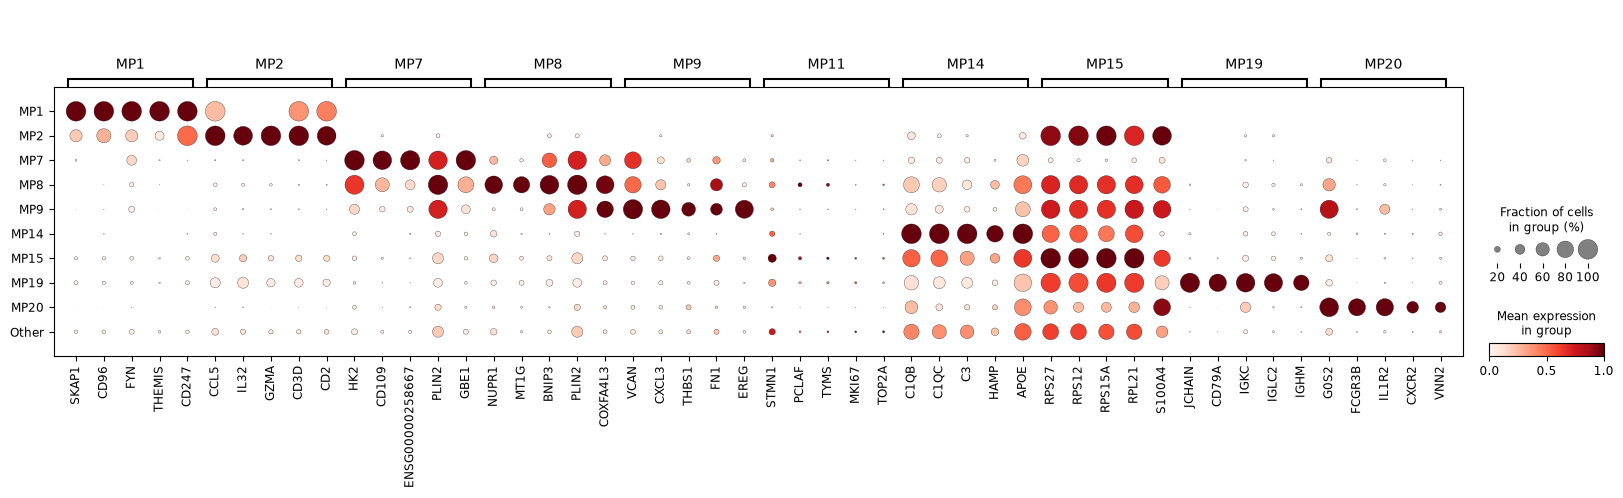

In [ ]:
# dotplot needs normalized/log data; skip if already normalized (check adata.X.max() first)
checkpoint(f"adata.X max value: {adata.X.max():.2f} (if this looks like raw counts, normalize first)")
# Uncomment if adata.X still holds raw counts:
# sc.pp.normalize_total(adata, target_sum=1e4)
# sc.pp.log1p(adata)

# flatten gene dict into var_names groupby structure for sc.pl.dotplot, dropping genes not in adata
var_names_dict = {}
missing_genes = []
for mp, genes in mp_gene_dict.items():
    present = [g for g in genes if g in adata.var_names]
    missing = [g for g in genes if g not in adata.var_names]
    if missing:
        missing_genes.extend(missing)
    if present:
        var_names_dict[mp] = present

if missing_genes:
    checkpoint(f"WARNING: {len(missing_genes)} genes not found in adata.var_names: {missing_genes}")

existing_cats = adata.obs["dominant_MP_selected"].unique().tolist()
ordered_cats = [mp for mp in SELECTED_MPS if mp in existing_cats]
if "Other" in existing_cats:
    ordered_cats.append("Other")

checkpoint("Plotting dotplot (top genes per MP x cell type)")
fig = sc.pl.dotplot(
    adata,
    var_names=var_names_dict,
    groupby="dominant_MP_selected",
    categories_order=ordered_cats,
    standard_scale="var",  # scales each gene's dot size/color 0-1 across groups for easier comparison
    use_raw=False,     
    show=False,
    return_fig=True,
)
fig.make_figure()

fig.savefig(
    os.path.join(OUT_DIR, "05_16_dotplot_top_genes_75.pdf"),
    bbox_inches="tight",
    dpi=300,
)

plt.close()
checkpoint(f"Dotplot saved to {os.path.join(OUT_DIR, '05_16_dotplot_top_genes_75.pdf')}")
checkpoint("ALL DONE!")